# Thesis: Pediatric vs Adult Dengue Severity Prediction with Subgroup-Specific SHAP Explanations

**Context & Methodology:**
- **Objective**: Identify divergent physiological drivers of Dengue severity between Pediatric (<=18) and Adult (>18) cohorts.
- **Dataset**: Mendeley Data - Comprehensive Dengue Hematology and Clinical Dataset from Bangladesh.
- **Approach**: Age-stratified ML framework involving pooled and subgroup-specific models, interpreted via localized SHAP analysis.
- **Severity Target Harmonization**: Consistent with Niazi & Momand (2026), severity is derived from platelet counts (Minor, Moderate, Severe). For binary classification, we use Severe vs Non-Severe.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, matthews_corrcoef
from scipy.stats import kendalltau
from IPython.display import display

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 1. Data Ingestion & Preprocessing
We load the dataset and perform initial preprocessing. We harmonize the target with the 3-tier severity proxy from Niazi & Momand (2026).


In [2]:
# 1. Load Data
file_path = 'Comprehensive Dengue Hematology and Clinical Datas/Dengue Hematology Dataset_bd.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"Dataset Loaded. Shape: {df.shape}")
else:
    raise FileNotFoundError(f"File not found at {file_path}")

# Display columns
print(df.columns)


Dataset Loaded. Shape: (1329, 13)
Index(['SN', 'Age', 'Sex', 'Dengue NS1', 'PLT', 'WBC', 'HCT', 'RBC', 'Lymph %',
       'Neut %', 'ALT', 'AST', 'Unnamed: 12'],
      dtype='object')


In [3]:
# 2. Preprocessing & Target Harmonization

# Filter for Dengue Positive patients only
if 'Dengue NS1' in df.columns:
    df = df[df['Dengue NS1'].str.lower() == 'positive'].copy()

# Rename columns for ease of use
df = df.rename(columns={'Sex': 'Gender'})

# Convert Gender to binary
if 'Gender' in df.columns:
    df['Gender'] = df['Gender'].replace({'Male': 0, 'Female': 1, 'male': 0, 'female': 1})

# Median imputation for missing values
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Deriving Severity Target (Niazi & Momand 2026 criteria based on Platelet Count)
# PLT is in K/uL (e.g., 50.0 means 50,000)
def derive_severity_3tier(plt):
    if plt < 50.0:
        return 'Severe'
    elif plt < 100.0:
        return 'Moderate'
    else:
        return 'Minor'

df['Severity_3Tier'] = df['PLT'].apply(derive_severity_3tier)

# Binary Target: Severe vs Non-Severe (Minor/Moderate)
df['Target'] = df['Severity_3Tier'].apply(lambda x: 1 if x == 'Severe' else 0)

print(df['Severity_3Tier'].value_counts())
print(df['Target'].value_counts())


Severity_3Tier
Severe      413
Minor       312
Moderate    247
Name: count, dtype: int64
Target
0    559
1    413
Name: count, dtype: int64


## 2. Exploratory Data Analysis (EDA)
Visualize key hematological markers across Pediatric vs Adult cohorts.


In [4]:
df_plot = df.copy()
df_plot['Cohort'] = df_plot['Age'].apply(lambda x: 'Pediatric (<=18)' if x <= 18 else 'Adult (>18)')

eda_features = ['PLT', 'WBC', 'HCT', 'Lymph %']
eda_features = [f for f in eda_features if f in df.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(eda_features):
    sns.boxplot(x='Cohort', y=col, data=df_plot, ax=axes[i], palette='Set2', hue='Cohort', legend=False)
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('pediatric_vs_adult_eda.png')
plt.close()


## 3. Feature Engineering
We create domain-driven features based on clinical thresholds as requested in the proposal (Phase 4).


In [5]:
# 3. Feature Engineering

# Platelet Critical Low (< 50,000)
df['platelet_critical_low'] = (df['PLT'] < 50.0).astype(int)

# Platelet Severe Low (< 20,000)
df['platelet_severe_low'] = (df['PLT'] < 20.0).astype(int)

# WBC Leukopenia (< 4,000)
df['wbc_leukopenia'] = (df['WBC'] < 4.0).astype(int)

# Lymphopenia (< 20%)
if 'Lymph %' in df.columns:
    df['lymph_low'] = (df['Lymph %'] < 20.0).astype(int)

# Neutrophilia (> 70%)
if 'Neut %' in df.columns:
    df['neut_high'] = (df['Neut %'] > 70.0).astype(int)

# AST / ALT ratio and Liver Involvement
if 'AST' in df.columns and 'ALT' in df.columns:
    df['ast_alt_ratio'] = df['AST'] / (df['ALT'] + 1e-5)
    # Liver involvement proxy (upper limit > 40 U/L)
    df['liver_involvement'] = ((df['AST'] > 40.0) | (df['ALT'] > 40.0)).astype(int)
    # AST to Platelet Ratio Index (APRI proxy)
    df['ast_to_platelet_ratio_index'] = df['AST'] / (df['PLT'] + 1e-5)

# PLT to WBC ratio
df['plt_to_wbc_ratio'] = df['PLT'] / (df['WBC'] + 1e-5)

# Age Decade
df['age_decade'] = pd.cut(df['Age'], bins=[0, 9, 19, 29, 39, 49, 59, 69, 79, 100], labels=False)

# Gender x Age interaction
df['gender_age_int'] = df['Gender'] * df['Age']

# Select final features
excluded_cols = ['SN', 'Dengue NS1', 'Severity_3Tier', 'Target', 'Unnamed: 12']
features = [c for c in df.columns if c not in excluded_cols]

# Remove data leakage features that perfectly determine the proxy target
leaky_features = ['PLT', 'platelet_critical_low', 'platelet_severe_low', 'ast_to_platelet_ratio_index', 'plt_to_wbc_ratio']
features = [f for f in features if f not in leaky_features]

print(f"Engineered Features (Leakage Removed): {features}")


Engineered Features (Leakage Removed): ['Age', 'Gender', 'WBC', 'HCT', 'RBC', 'Lymph %', 'Neut %', 'ALT', 'AST', 'wbc_leukopenia', 'lymph_low', 'neut_high', 'ast_alt_ratio', 'liver_involvement', 'age_decade', 'gender_age_int']


## 4. Stratified Model Training & Evaluation
We split the dataset into Pediatric and Adult cohorts, train five classifiers (LR, RF, XGB, LGBM, Stacking) per cohort, and evaluate.


In [6]:
# 4. Stratified Model Training

# Subgroups
pediatric_mask = df['Age'] <= 18
adult_mask = df['Age'] > 18

cohorts = {
    'Pooled': df,
    'Pediatric': df[pediatric_mask],
    'Adult': df[adult_mask]
}

# Define Base Models
def get_models():
    return {
        'LR': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED),
        'RF': RandomForestClassifier(class_weight='balanced', random_state=RANDOM_SEED),
        'XGB': XGBClassifier(scale_pos_weight=(df['Target'].value_counts()[0]/df['Target'].value_counts()[1]), random_state=RANDOM_SEED, eval_metric='logloss'),
        'LGBM': LGBMClassifier(class_weight='balanced', random_state=RANDOM_SEED, verbose=-1)
    }

# Function to train and evaluate
def train_evaluate(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    
    models = get_models()
    
    # Define Stacking Classifier
    estimators = [(name, model) for name, model in models.items()]
    stacking_clf = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
    models['Stacking'] = stacking_clf
    
    results = {}
    trained_models = {}
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
        
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        
        # Calculate Sensitivity & Specificity
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        sensitivity = tp / (tp + fn)
        specificity = tn / (tn + fp)
        
        # Matthews Correlation Coefficient
        # Handling the import for matthews_corrcoef
        from sklearn.metrics import matthews_corrcoef
        mcc = matthews_corrcoef(y_test, y_pred)
        
        results[name] = {
            'Accuracy': acc,
            'AUC': auc,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'F1': f1,
            'MCC': mcc
        }
        trained_models[name] = model
        
    return results, trained_models, X_train, X_test

# Run for each cohort
all_results = {}
all_models = {}
all_data = {}

for cohort_name, cohort_df in cohorts.items():
    print(f"\n--- Training {cohort_name} Cohort (n={len(cohort_df)}) ---")
    X = cohort_df[features]
    y = cohort_df['Target']
    
    # If a cohort has only 1 class in target, skip or handle
    if len(y.unique()) < 2:
        print(f"Skipping {cohort_name} due to single class in target.")
        continue
        
    res, models_dict, X_tr, X_te = train_evaluate(X, y)
    all_results[cohort_name] = res
    all_models[cohort_name] = models_dict
    all_data[cohort_name] = {'X_train': X_tr, 'X_test': X_te, 'y_test': y.loc[X_te.index]}

# Format results
res_dfs = []
for cohort, res in all_results.items():
    df_res = pd.DataFrame(res).T
    df_res['Cohort'] = cohort
    res_dfs.append(df_res)

final_results = pd.concat(res_dfs)
display(final_results)



--- Training Pooled Cohort (n=972) ---



--- Training Pediatric Cohort (n=158) ---



--- Training Adult Cohort (n=814) ---


,Accuracy,AUC,Sensitivity,Specificity,F1,MCC,Cohort
LR,0.635897,0.711489,0.662651,0.616071,0.607735,0.275626,Pooled
RF,0.789744,0.859671,0.698795,0.857143,0.738854,0.566456,Pooled
XGB,0.733333,0.833692,0.698795,0.758929,0.690476,0.456400,Pooled
LGBM,0.769231,0.827560,0.698795,0.821429,0.720497,0.525047,Pooled
Stacking,0.758974,0.856175,0.674699,0.821429,0.704403,0.502992,Pooled
LR,0.718750,0.681159,0.555556,0.782609,0.526316,0.328021,Pediatric
RF,0.906250,0.961353,0.666667,1.000000,0.800000,0.767948,Pediatric
XGB,0.843750,0.898551,0.777778,0.869565,0.736842,0.627926,Pediatric
LGBM,0.875000,0.884058,0.777778,0.913043,0.777778,0.690821,Pediatric
Stacking,0.906250,0.946860,0.666667,1.000000,0.800000,0.767948,Pediatric


## 5. Subgroup-Specific SHAP Interpretations
Using SHAP to extract feature importance and dependence plots for the best model (Random Forest/XGBoost).


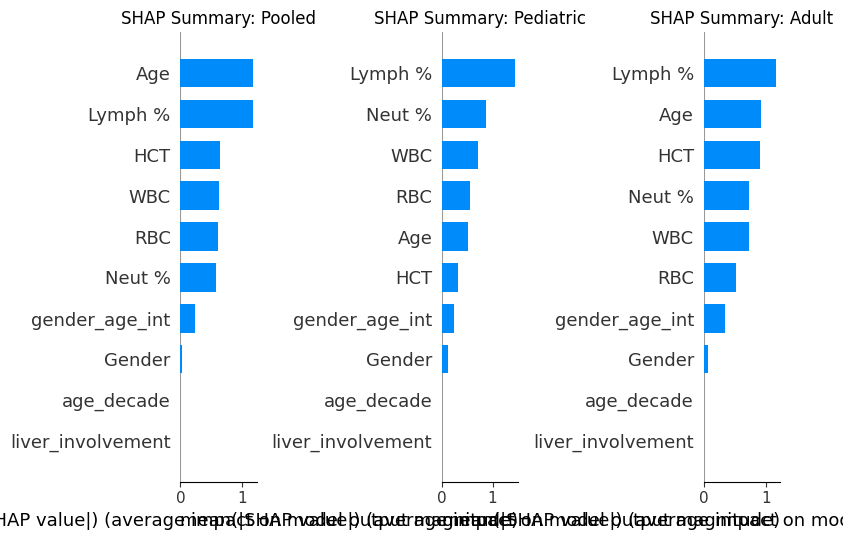

In [7]:
# SHAP Analysis
shap_values_dict = {}
shap_explainers = {}

# Use XGBoost for SHAP as TreeExplainer works well
model_to_explain = 'XGB'

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

for i, cohort in enumerate(['Pooled', 'Pediatric', 'Adult']):
    if cohort not in all_models:
        continue
        
    model = all_models[cohort][model_to_explain]
    X_test = all_data[cohort]['X_test']
    
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)
    
    shap_values_dict[cohort] = shap_values
    shap_explainers[cohort] = explainer
    
    plt.subplot(1, 3, i+1)
    plt.title(f"SHAP Summary: {cohort}")
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=False, max_display=10)

plt.tight_layout()
plt.savefig('shap_summary_comparison.png')
plt.show()


## 6. Feature Ranking Comparison
We quantify the disagreement between paired SHAP rankings using Kendall's tau-b.


In [8]:
from scipy.stats import kendalltau

def get_feature_ranking(shap_vals, feature_names):
    mean_abs_shap = np.abs(shap_vals).mean(axis=0)
    ranking = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)
    return ranking

rankings = {}
for cohort in ['Pooled', 'Pediatric', 'Adult']:
    if cohort in shap_values_dict:
        X_test = all_data[cohort]['X_test']
        rankings[cohort] = get_feature_ranking(shap_values_dict[cohort], X_test.columns)

print("--- Top 5 Features ---")
for cohort, rank in rankings.items():
    print(f"\n{cohort}:")
    print(rank.head(5))

if 'Pediatric' in rankings and 'Adult' in rankings:
    # Ensure same feature order
    features_ordered = rankings['Pooled'].index.tolist()
    
    rank_ped = [rankings['Pediatric'].index.get_loc(f) for f in features_ordered]
    rank_ad = [rankings['Adult'].index.get_loc(f) for f in features_ordered]
    rank_pool = [rankings['Pooled'].index.get_loc(f) for f in features_ordered]
    
    tau_ped_ad, _ = kendalltau(rank_ped, rank_ad)
    tau_ped_pool, _ = kendalltau(rank_ped, rank_pool)
    tau_ad_pool, _ = kendalltau(rank_ad, rank_pool)
    
    print(f"\nKendall's tau-b (Pediatric vs Adult): {tau_ped_ad:.3f}")
    print(f"Kendall's tau-b (Pediatric vs Pooled): {tau_ped_pool:.3f}")
    print(f"Kendall's tau-b (Adult vs Pooled): {tau_ad_pool:.3f}")


--- Top 5 Features ---

Pooled:
Age        1.178607
Lymph %    1.173444
HCT        0.642997
WBC        0.626050
RBC        0.617946
dtype: float32

Pediatric:
Lymph %    1.438237
Neut %     0.876272
WBC        0.713971
RBC        0.561596
Age        0.521685
dtype: float32

Adult:
Lymph %    1.173001
Age        0.921604
HCT        0.905061
Neut %     0.736554
WBC        0.727516
dtype: float32

Kendall's tau-b (Pediatric vs Adult): 0.900
Kendall's tau-b (Pediatric vs Pooled): 0.850
Kendall's tau-b (Adult vs Pooled): 0.950


## 7. Age-Aware Clinical Decision Framework
Translating SHAP outputs into a structured clinical decision framework by examining SHAP dependence plots.


In [9]:
# SHAP Dependence plot for AST
for cohort in ['Pediatric', 'Adult']:
    if cohort in shap_explainers:
        shap.dependence_plot("AST", shap_values_dict[cohort], all_data[cohort]['X_test'], show=False)
        plt.title(f"Dependence Plot: AST ({cohort})")
        plt.savefig(f'shap_dependence_AST_{cohort}.png')
        plt.close()

# SHAP Dependence plot for WBC
for cohort in ['Pediatric', 'Adult']:
    if cohort in shap_explainers:
        shap.dependence_plot("WBC", shap_values_dict[cohort], all_data[cohort]['X_test'], show=False)
        plt.title(f"Dependence Plot: WBC ({cohort})")
        plt.savefig(f'shap_dependence_WBC_{cohort}.png')
        plt.close()


## 8. Programmatic SHAP-Derived Clinical Threshold Extraction
To solidify the Age-Aware Clinical Decision Framework (Phase 9 of proposal), we programmatically extract the exact clinical cutoff values for the top features where the risk of severe Dengue becomes significantly elevated (SHAP value > 0).


In [10]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

print("--- Extracted Clinical Cutoffs for Severe Dengue Risk (SHAP > 0) ---")
for cohort in ['Pediatric', 'Adult']:
    if cohort in shap_explainers:
        print(f"\nCohort: {cohort}")
        X_test = all_data[cohort]['X_test']
        shap_vals = shap_values_dict[cohort]
        
        # Identify top 3 continuous features by mean absolute SHAP
        mean_abs_shap = np.abs(shap_vals).mean(axis=0)
        top_features = pd.Series(mean_abs_shap, index=X_test.columns).sort_values(ascending=False)
        continuous_top = [f for f in top_features.index if X_test[f].nunique() > 2][:3]
        
        for feature in continuous_top:
            feature_idx = X_test.columns.get_loc(feature)
            feature_values = X_test.iloc[:, feature_idx].values.reshape(-1, 1)
            feature_shap = shap_vals[:, feature_idx]
            
            # Binary target: Does this feature's value push the model towards Severe risk?
            risk_elevated = (feature_shap > 0).astype(int)
            
            # Use a depth-1 Decision Tree to find the optimal split point
            dt = DecisionTreeClassifier(max_depth=1, random_state=42)
            try:
                dt.fit(feature_values, risk_elevated)
                if dt.tree_.node_count > 1:
                    threshold = dt.tree_.threshold[0]
                    direction = "<=" if dt.tree_.value[1][0][1] > dt.tree_.value[2][0][1] else ">"
                    print(f"  - {feature}: High Risk when {direction} {threshold:.2f}")
                else:
                    print(f"  - {feature}: No single threshold found (monotonic impact)")
            except:
                pass


--- Extracted Clinical Cutoffs for Severe Dengue Risk (SHAP > 0) ---

Cohort: Pediatric
  - Lymph %: High Risk when > 44.50
  - Neut %: High Risk when <= 48.00
  - WBC: High Risk when <= 4.34

Cohort: Adult
  - Lymph %: High Risk when > 24.99
  - Age: High Risk when > 31.00
  - HCT: High Risk when > 40.65
